In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("../data/processed/clean_data.csv")

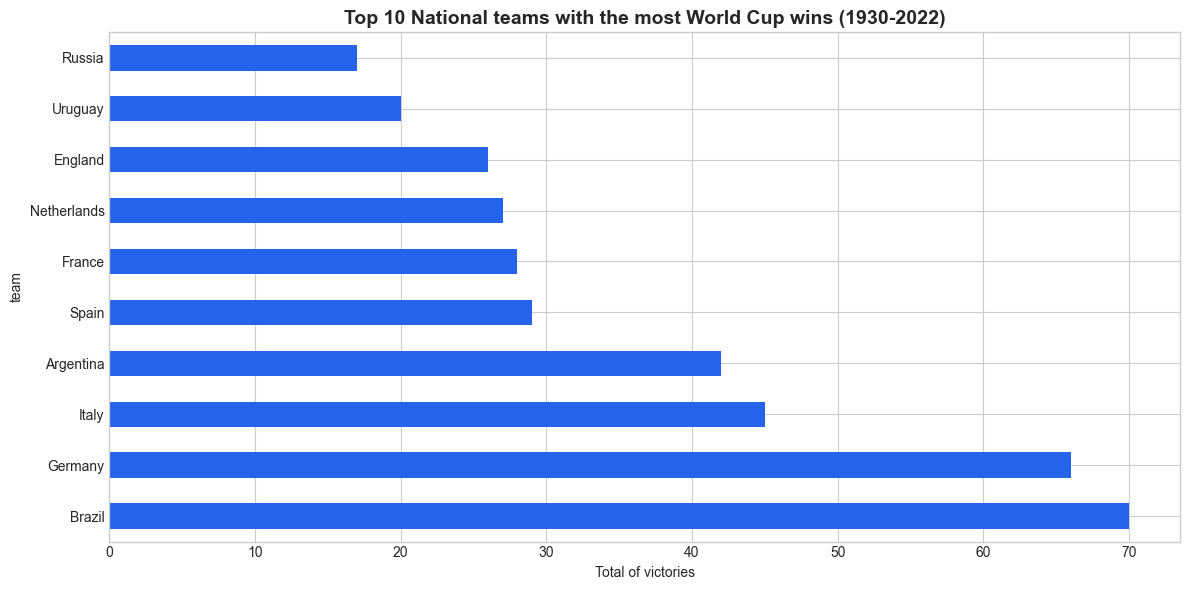

In [3]:
plt.style.use("seaborn-v0_8-whitegrid")
COLORES = ["#2563eb", "#16a34a", "#dc2626", "#d97706", "#7c3aed"]

# --- Top 10 theams with more victories ---
fig, ax = plt.subplots(figsize=(12, 6))
top10 = df.groupby("team")["wins"].sum().nlargest(10)
top10.plot(kind="barh", color=COLORES[0], ax=ax)
ax.set_title("Top 10 National teams with the most World Cup wins (1930-2022)", 
             fontsize=14, fontweight="bold")
ax.set_xlabel("Total of victories")
plt.tight_layout()
plt.savefig("../outputs/figures/01_top10_victories.png", dpi=150)
plt.show()

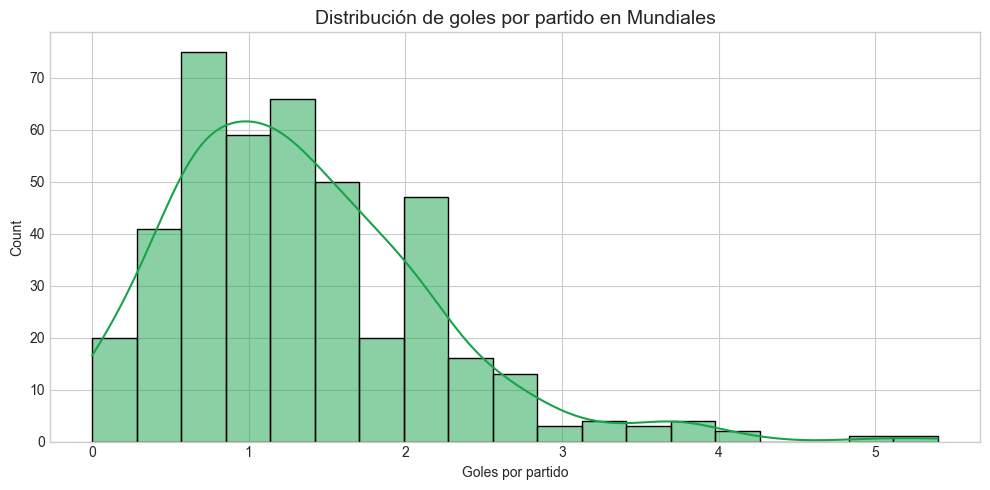

In [ ]:
# --- Distribution of goals per match ---
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df["goals_per_match"], kde=True, color=COLORES[1], ax=ax)
ax.set_title("Distribution of goals per match in World Cups", fontsize=14)
ax.set_xlabel("Goals per match")
plt.tight_layout()
plt.savefig("../outputs/figures/02_distribution_goals.png", dpi=150)
plt.show()

NameError: name 'COLORES' is not defined

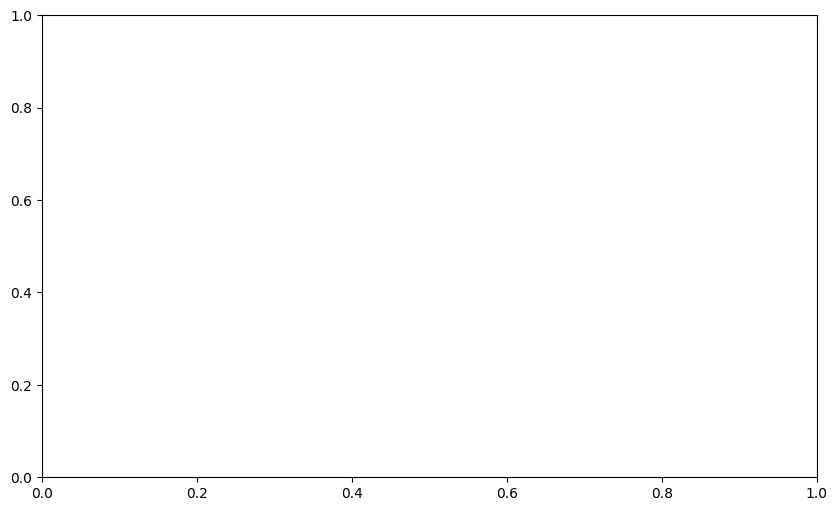

In [2]:
# --- Performance by confederation ---
# Basic team-to-confederation mapping for historical World Cup teams.
confederation_mapping = {
    "Argentina": "CONMEBOL",
    "Brazil": "CONMEBOL",
    "Uruguay": "CONMEBOL",
    "Chile": "CONMEBOL",
    "Colombia": "CONMEBOL",
    "Paraguay": "CONMEBOL",
    "Peru": "CONMEBOL",
    "Ecuador": "CONMEBOL",
    "Bolivia": "CONMEBOL",

    "Germany": "UEFA",
    "France": "UEFA",
    "Spain": "UEFA",
    "Italy": "UEFA",
    "England": "UEFA",
    "Netherlands": "UEFA",
    "Portugal": "UEFA",
    "Belgium": "UEFA",
    "Croatia": "UEFA",
    "Switzerland": "UEFA",
    "Sweden": "UEFA",
    "Denmark": "UEFA",
    "Poland": "UEFA",

    "Mexico": "CONCACAF",
    "United States": "CONCACAF",
    "Costa Rica": "CONCACAF",
    "Canada": "CONCACAF",

    "Japan": "AFC",
    "Korea Republic": "AFC",
    "Iran": "AFC",
    "Saudi Arabia": "AFC",
    "Australia": "AFC",

    "Cameroon": "CAF",
    "Nigeria": "CAF",
    "Ghana": "CAF",
    "Morocco": "CAF",
    "Senegal": "CAF",
    "South Africa": "CAF",

    "New Zealand": "OFC"
}

# Add confederation column based on team name.
df["confederation"] = df["team"].map(confederation_mapping)

# Keep only teams with known confederation.
df_confederation = df.dropna(subset=["confederation"])

fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df_confederation,
    x="confederation",
    y="goals_per_match",
    hue="confederation",
    palette=COLORES,
    ax=ax,
    legend=False
)

ax.set_title("Offensive Performance by Confederation", fontsize=14)
ax.set_xlabel("Confederation")
ax.set_ylabel("Goals per Match")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../outputs/figures/03_confederations.png", dpi=150)
plt.show()